In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load

df = pd.read_csv("plantar_features.csv")
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}\n")

Dataset shape: (4962, 8)
Label distribution:
label
flat foot    1848
over-arch    1586
normal       1528
Name: count, dtype: int64



In [3]:
# Encode Labels

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)} → {list(range(len(le.classes_)))}\n")

Classes: ['flat foot', 'normal', 'over-arch'] → [0, 1, 2]



In [4]:
# Features and Target

FEATURE_COLS = [
    "mean_pressure", "max_pressure", "contact_area",
    "cop_x", "cop_y"
]

X = df[FEATURE_COLS].values
y = df["label_enc"].values

print(f"Feature matrix: {X.shape}")
print(f"Any NaNs: {np.isnan(X).sum()}\n")

Feature matrix: (4962, 5)
Any NaNs: 0



In [5]:
# Single-Split(Sanity check)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}\n")


Train size: 3969 | Test size: 993



In [6]:
# Class Weights

classes, counts = np.unique(y_train, return_counts=True)
total = len(y_train)
class_weights = {cls: total / (len(classes) * cnt)
                 for cls, cnt in zip(classes, counts)}
sample_weights = np.array([class_weights[label] for label in y_train])

In [7]:
# Train XGBoost

num_classes = len(le.classes_)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic" if num_classes == 2 else "multi:softprob",
    num_class=None if num_classes == 2 else num_classes,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:34:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1, num_class=3, ...)

In [8]:
# Evaluate

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

if num_classes == 2:
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC-AUC  : {auc:.4f}\n")
else:
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro-OvR): {auc:.4f}\n")

Accuracy : 64.65%

Classification Report:
              precision    recall  f1-score   support

   flat foot       0.80      0.65      0.72       370
      normal       0.55      0.81      0.65       306
   over-arch       0.64      0.49      0.55       317

    accuracy                           0.65       993
   macro avg       0.66      0.65      0.64       993
weighted avg       0.67      0.65      0.64       993

ROC-AUC (macro-OvR): 0.8249



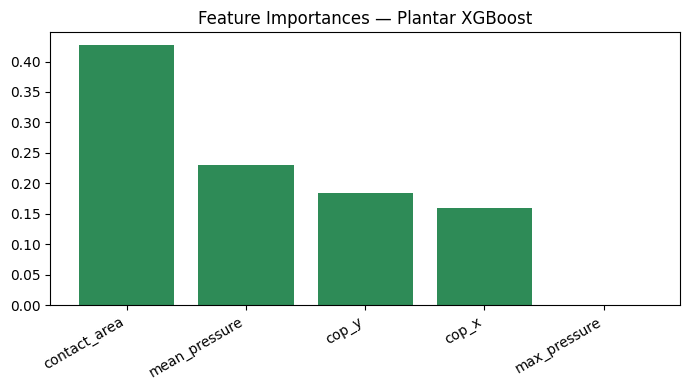


Top 3 most predictive features:
  1. contact_area — 0.4266
  2. mean_pressure — 0.2295
  3. cop_y — 0.1848

Plantar XGBoost pipeline verified end-to-end.


In [9]:
# Feature Importance

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(range(len(FEATURE_COLS)),
        importances[indices], color="seagreen")
plt.xticks(range(len(FEATURE_COLS)),
           [FEATURE_COLS[i] for i in indices], rotation=30, ha="right")
plt.title("Feature Importances — Plantar XGBoost")
plt.tight_layout()
plt.savefig("plantar_xgb_feature_importance.png", dpi=150)
plt.show()

print("\nTop 3 most predictive features:")
for i in range(3):
    print(f"  {i+1}. {FEATURE_COLS[indices[i]]} — {importances[indices[i]]:.4f}")

print("\nPlantar XGBoost pipeline verified end-to-end.")

In [11]:
!pip install optuna -q

import optuna
from sklearn.model_selection import StratifiedKFold, GridSearchCV
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 2, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 2.0),
        "objective":         "binary:logistic" if num_classes == 2 else "multi:softprob",
        "eval_metric":       "logloss",
        "use_label_encoder": False,
        "random_state":      42,
        "n_jobs":            -1,
    }
    if num_classes > 2:
        params["num_class"] = num_classes

    clf = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        w_tr        = sample_weights[train_idx]

        clf.fit(X_tr, y_tr, sample_weight=w_tr)
        y_prob = clf.predict_proba(X_val)

        if num_classes == 2:
            scores.append(roc_auc_score(y_val, y_prob[:, 1]))
        else:
            scores.append(roc_auc_score(y_val, y_prob, multi_class="ovr", average="macro"))

    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV): {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

# Refit with best params

best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    "objective":         "binary:logistic" if num_classes == 2 else "multi:softprob",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "random_state":      42,
    "n_jobs":            -1,
})
if num_classes > 2:
    best_xgb_params["num_class"] = num_classes

best_xgb = xgb.XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_opt = best_xgb.predict(X_test)
y_prob_opt = best_xgb.predict_proba(X_test)

print(f"\nOptuna-tuned XGB — Test Accuracy: {accuracy_score(y_test, y_pred_opt)*100:.2f}%")
print(classification_report(y_test, y_pred_opt, target_names=le.classes_))

if num_classes == 2:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt[:, 1]):.4f}")
else:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt, multi_class='ovr', average='macro'):.4f}")

# GridSearch around Optuna best region

bp = study_xgb.best_params
grid_params = {
    "n_estimators":  [max(50, bp["n_estimators"]-100), bp["n_estimators"], bp["n_estimators"]+100],
    "max_depth":     [max(2, bp["max_depth"]-1), bp["max_depth"], bp["max_depth"]+1],
    "learning_rate": [round(bp["learning_rate"]*0.5, 4), round(bp["learning_rate"], 4), round(bp["learning_rate"]*1.5, 4)],
    "subsample":     [round(max(0.5, bp["subsample"]-0.1), 1), round(bp["subsample"], 1)],
}

gs_xgb = GridSearchCV(
    xgb.XGBClassifier(
        objective        = "binary:logistic" if num_classes == 2 else "multi:softprob",
        eval_metric      = "logloss",
        use_label_encoder= False,
        random_state     = 42,
        n_jobs           = -1,
    ),
    grid_params,
    cv      = 3,
    scoring = "roc_auc" if num_classes == 2 else "roc_auc_ovr",
    n_jobs  = -1,
    verbose = 1,
)
gs_xgb.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nGridSearch best params : {gs_xgb.best_params_}")
print(f"GridSearch best CV AUC : {gs_xgb.best_score_:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:37:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:37:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:37:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:37:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Best ROC-AUC (CV): 0.8290
Best params: {'n_estimators': 402, 'max_depth': 7, 'learning_rate': 0.06916927970729943, 'subsample': 0.9786883368127648, 'colsample_bytree': 0.8003557332256587, 'gamma': 0.02797970167106456, 'reg_alpha': 1.4956414830700446}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:39:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Optuna-tuned XGB — Test Accuracy: 68.28%
              precision    recall  f1-score   support

   flat foot       0.78      0.72      0.75       370
      normal       0.63      0.75      0.68       306
   over-arch       0.64      0.58      0.61       317

    accuracy                           0.68       993
   macro avg       0.68      0.68      0.68       993
weighted avg       0.69      0.68      0.68       993

ROC-AUC: 0.8635
Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:43:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



GridSearch best params : {'learning_rate': 0.1038, 'max_depth': 7, 'n_estimators': 502, 'subsample': 1.0}
GridSearch best CV AUC : 0.8392
